In [1]:
############## Explore Beaufort Shelfbreak Cloud Cover ##################
# The purpose of this script is to explore the cloud cover in ERA5 data
# in the region of the Beaufort shelfbreak jet that we are analyzing. 
# If appropriate, an idealized curve will be fit to the data to be used
# as input into the ROMS-BUDGELL idealized model. 
#
# Notes:
# -
#
######################################################################

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [2]:
# Load in the packages
import xarray as xr
import numpy as np
import cartopy
import glob
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.feature as cfeature
import cmocean.cm as cmo
import matplotlib.pyplot as plt
import matplotlib.ticker as tick
import warnings
import numpy as np
from netCDF4 import Dataset
import datetime
from datetime import datetime
import matplotlib.dates as mdates
import pandas as pd
import xroms
from matplotlib import ticker
crs = ccrs.PlateCarree()
warnings.filterwarnings("ignore") 
#Cartopy
land_10m = cfeature.NaturalEarthFeature('physical', 'land', '10m',
                                edgecolor='face',
                                facecolor=cfeature.COLORS['land'])

from xhistogram.xarray import histogram

In [3]:
# Load in the ERA5 mean net downward longwave radiation
era5_cloud = xr.open_dataset('/pscratch/sd/b/bundzis/Beaufort_ROMS_2020_dvd_myroms_ice_scratch/External_data/ERA5_data/tot_cloud_cover_era5_2017_2024.nc')
era5_cloud

<xarray.Dataset> Size: 454MB
Dimensions:     (valid_time: 70128, longitude: 77, latitude: 21)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 561kB 2017-01-01 ... 2024-12-31T2...
  * longitude   (longitude) float64 616B -156.0 -155.8 -155.5 ... -137.2 -137.0
  * latitude    (latitude) float64 168B 73.0 72.75 72.5 ... 68.5 68.25 68.0
Data variables:
    tcc         (valid_time, latitude, longitude) float32 454MB ...
Attributes:
    CDI:                     Climate Data Interface version 2.5.0 (https://mp...
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    history:                 Mon Aug 11 10:54:26 2025: cdo mergetime tot_clou...
    CDO:                     Climate Data Operators version 2.5.0 (https://mp...

In [4]:
era5_cloud.tcc

<xarray.DataArray 'tcc' (valid_time: 70128, latitude: 21, longitude: 77)> Size: 454MB
[113396976 values with dtype=float32]
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 561kB 2017-01-01 ... 2024-12-31T2...
  * longitude   (longitude) float64 616B -156.0 -155.8 -155.5 ... -137.2 -137.0
  * latitude    (latitude) float64 168B 73.0 72.75 72.5 ... 68.5 68.25 68.0
Attributes: (12/32)
    standard_name:                            cloud_area_fraction
    long_name:                                Total cloud cover
    units:                                    (0 - 1)
    GRIB_paramId:                             164
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1617
    ...                                       ...
    GRIB_missingValue:                        3.4028234663852886e+38
    GRIB_name:                                Total cloud cover
    GRIB_shortName:                           tcc
    GRIB_totalNumber:                         0
    GRIB_units:                               (0 - 1)
    GRIB_surface:                             0.0

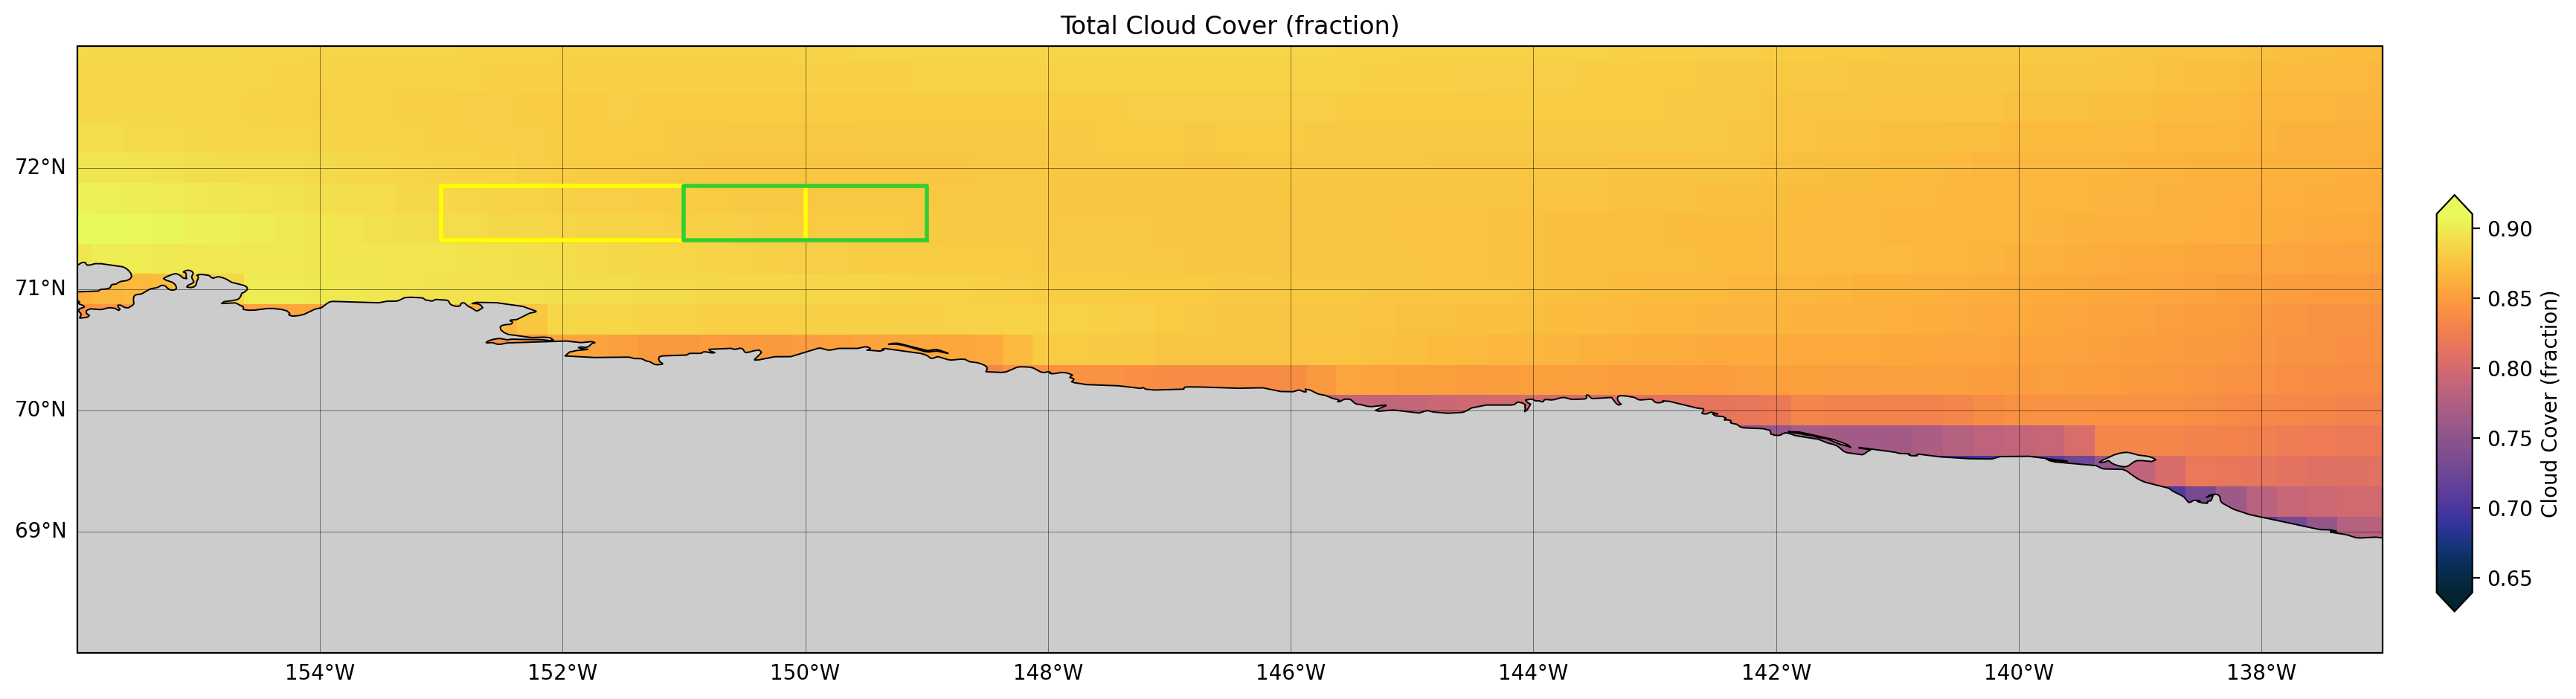

In [5]:
# Plot means
# Put both boxes

# Make bathymetry levels
lev_bathy = np.arange(10,110,10)

# Make the figure 
fig, ax = plt.subplots(figsize=(16,8), dpi=200,
                       constrained_layout=True, 
                       subplot_kw={'projection': crs})

# Plot surface u at 2019-09-01 
m1 = era5_cloud.tcc.mean(dim='valid_time').plot(
    x='longitude', y='latitude',
    ax=ax,
    cmap=cmo.thermal, transform=ccrs.PlateCarree(),
    add_colorbar=False, facecolor="gray",
)
ax.set_title('Total Cloud Cover (fraction)')

# Make a colorbar for each plot
# Longwave
cbar_ax1 = fig.add_axes([1.02,0.28,0.015,0.35])
fig.colorbar(m1,ax=ax,extend='both',
             label='Cloud Cover (fraction)',
             pad=0.03, cax=cbar_ax1)

# Add other details to each subplot
# Set extent and map features
ax.set_extent([-156,-137,68, 73],ccrs.PlateCarree())
ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '10m',
                                            facecolor='0.8'), linewidth=.7)
ax.coastlines(resolution='10m', linewidth=.7)

# Add bathymetry for the domain
#ax.contour(grid.lon_rho, grid.lat_rho, grid.h, levels=lev_bathy, colors='dimgrey')

gl = ax.gridlines(crs=ccrs.PlateCarree(), 
                draw_labels=True, 
                x_inline=False, y_inline=False, 
                linewidth=0.33, color='k',alpha=0.5)
gl.right_labels = gl.top_labels = False
gl.xlocator = ticker.FixedLocator([-156, -154, -152, -150,-148,-146,-144,-142, -140, -138])
gl.xlabel_style = {'rotation': 0, 'ha': 'center'}

# Pick a region to analyze 
# Box 1
box_min_lon_01 = -150
box_max_lon_01 = -153
box_min_lat_01 = 71.4
box_max_lat_01 = 71.85
# Plot Box 1
ax.plot([box_min_lon_01, box_max_lon_01, box_max_lon_01, box_min_lon_01, box_min_lon_01],
        [box_min_lat_01, box_min_lat_01, box_max_lat_01, box_max_lat_01, box_min_lat_01],
        color='yellow', linestyle='-', linewidth=2)
# Box 2
box_min_lon_02 = -149
box_max_lon_02 = -151
box_min_lat_02 = 71.4
box_max_lat_02 = 71.85
# Plot Box 2
ax.plot([box_min_lon_02, box_max_lon_02, box_max_lon_02, box_min_lon_02, box_min_lon_02],
        [box_min_lat_02, box_min_lat_02, box_max_lat_02, box_max_lat_02, box_min_lat_02],
        color='limegreen', linestyle='-', linewidth=2)

fig.canvas.draw()

In [6]:
print('ERA5 cloud cover min: ', era5_cloud.tcc.min().values)
print('ERA5 cloud cover max: ', era5_cloud.tcc.max().values)
print('ERA5 cloud cover mean: ', era5_cloud.tcc.mean().values)
print('ERA5 cloud cover stddev: ', era5_cloud.tcc.std().values)

ERA5 cloud cover min:  0.0
ERA5 cloud cover max:  1.0
ERA5 cloud cover mean:  0.8116032
ERA5 cloud cover stddev:  0.31193385


In [7]:
# Trim to our boxes
# Convert to 360 bassed lat/lon
# Box 1
box_min_lon_01_360 = box_max_lon_01 + 360 
box_max_lon_01_360 = box_min_lon_01 + 360 
# Box 2
box_min_lon_02_360 = box_max_lon_02 + 360 
box_max_lon_02_360 = box_min_lon_02 + 360 


print('Box 1 Bounds:')
print('min_lon: ', str(box_min_lon_01) + ' (W) or ' + str(box_min_lon_01_360) + ' (0 - 360)')
print('max_lon: ', str(box_max_lon_01) + ' (W) or ' + str(box_max_lon_01_360) + ' (0 - 360)')
print('min_lat: ', box_min_lat_01)
print('max_lat: ', box_max_lat_01)
print('Box 2 Bounds:')
print('min_lon: ', str(box_min_lon_02) + ' (W) or ' + str(box_min_lon_02_360) + ' (0 - 360)')
print('max_lon: ', str(box_max_lon_02) + ' (W) or ' + str(box_max_lon_02_360) + ' (0 - 360)')
print('min_lat: ', box_min_lat_02)
print('max_lat: ', box_max_lat_02)

# Get the data in our two boxes
# Box 1
cloud_reg1 = era5_cloud.tcc.sel(longitude=slice(box_max_lon_01, box_min_lon_01), latitude=slice(72, 71))
# Box 2
cloud_reg2 = era5_cloud.tcc.sel(longitude=slice(box_max_lon_02, box_min_lon_02), latitude=slice(72, 71))

Box 1 Bounds:
min_lon:  -150 (W) or 207 (0 - 360)
max_lon:  -153 (W) or 210 (0 - 360)
min_lat:  71.4
max_lat:  71.85
Box 2 Bounds:
min_lon:  -149 (W) or 209 (0 - 360)
max_lon:  -151 (W) or 211 (0 - 360)
min_lat:  71.4
max_lat:  71.85


In [8]:
cloud_reg1

<xarray.DataArray 'tcc' (valid_time: 70128, latitude: 5, longitude: 13)> Size: 18MB
array([[[9.593201e-01, 9.412231e-01, ..., 6.463013e-01, 6.339111e-01],
        [1.000000e+00, 1.000000e+00, ..., 9.310913e-01, 9.189453e-01],
        ...,
        [1.000000e+00, 1.000000e+00, ..., 1.000000e+00, 1.000000e+00],
        [1.000000e+00, 1.000000e+00, ..., 1.000000e+00, 1.000000e+00]],

       [[9.950562e-01, 9.890442e-01, ..., 9.161377e-01, 9.159851e-01],
        [9.919128e-01, 9.919128e-01, ..., 1.000000e+00, 1.000000e+00],
        ...,
        [1.000000e+00, 1.000000e+00, ..., 1.000000e+00, 1.000000e+00],
        [1.000000e+00, 1.000000e+00, ..., 1.000000e+00, 1.000000e+00]],

       ...,

       [[0.000000e+00, 0.000000e+00, ..., 0.000000e+00, 0.000000e+00],
        [0.000000e+00, 0.000000e+00, ..., 0.000000e+00, 0.000000e+00],
        ...,
        [0.000000e+00, 0.000000e+00, ..., 0.000000e+00, 0.000000e+00],
        [0.000000e+00, 0.000000e+00, ..., 0.000000e+00, 0.000000e+00]],

       [[0.000000e+00, 0.000000e+00, ..., 6.988525e-03, 7.019043e-03],
        [0.000000e+00, 0.000000e+00, ..., 1.922607e-03, 1.892090e-03],
        ...,
        [0.000000e+00, 0.000000e+00, ..., 3.051758e-04, 3.051758e-04],
        [0.000000e+00, 0.000000e+00, ..., 2.349854e-03, 8.575439e-03]]],
      dtype=float32)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 561kB 2017-01-01 ... 2024-12-31T2...
  * longitude   (longitude) float64 104B -153.0 -152.8 -152.5 ... -150.2 -150.0
  * latitude    (latitude) float64 40B 72.0 71.75 71.5 71.25 71.0
Attributes: (12/32)
    standard_name:                            cloud_area_fraction
    long_name:                                Total cloud cover
    units:                                    (0 - 1)
    GRIB_paramId:                             164
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1617
    ...                                       ...
    GRIB_missingValue:                        3.4028234663852886e+38
    GRIB_name:                                Total cloud cover
    GRIB_shortName:                           tcc
    GRIB_totalNumber:                         0
    GRIB_units:                               (0 - 1)
    GRIB_surface:                             0.0

In [9]:
# Take the average over space but keep changes in time 
# Box 1 
cloud_reg1_avg = cloud_reg1.mean(dim=['latitude', 'longitude'])
# Box 2 
cloud_reg2_avg = cloud_reg2.mean(dim=['latitude', 'longitude'])

Text(0.5, 0, 'Year')

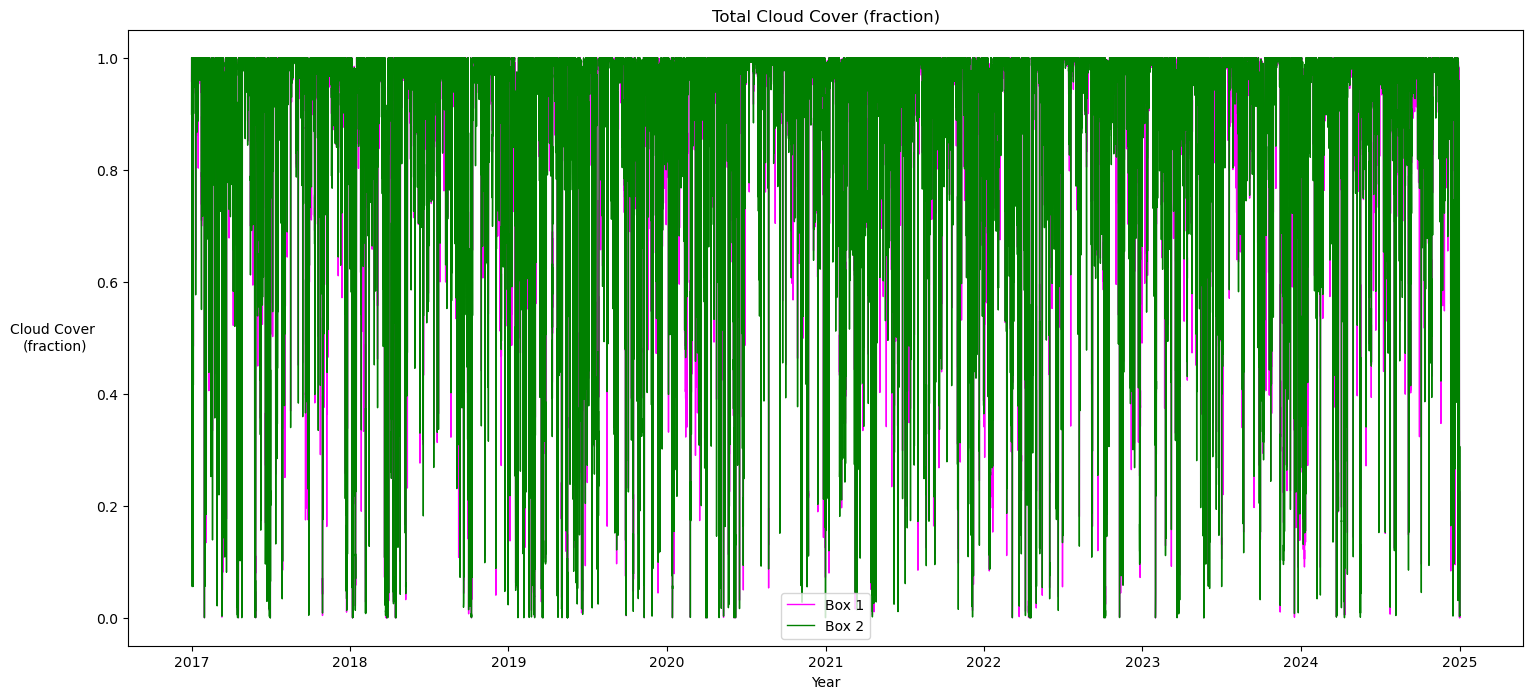

In [10]:
# Plot time series for these two regions (one panel for longwave
# and another for shortwave)

# Make the figure
fig, ax = plt.subplots(figsize=(18,8))

# Longwave
ax.plot(era5_cloud.valid_time, cloud_reg1_avg, color='magenta', linewidth=1, label='Box 1')
ax.plot(era5_cloud.valid_time, cloud_reg2_avg, color='green', linewidth=1, label='Box 2')
ax.set_title('Total Cloud Cover (fraction)')
ax.set_ylabel('Cloud Cover \n(fraction)', rotation=0, va='center', labelpad=30)
ax.legend()
ax.set_xlabel('Year')

In [11]:
# Make a version of the plot that has the average value
# for each day of each based on all of these years

# group by hour of day of year to rpeserve that frequency

# Box 1
cloud_reg1_avg_doy_hrly = cloud_reg1_avg.groupby(['valid_time.dayofyear', 'valid_time.hour']).mean('valid_time')
# Box 2
cloud_reg2_avg_doy_hrly = cloud_reg2_avg.groupby(['valid_time.dayofyear', 'valid_time.hour']).mean('valid_time')

In [13]:
# Reshape to be time series
# Dumb way would be to loop and we could just do that...
# Yup takes no time do the dumb way
# Box 1 
cloud_reg1_avg_doy_hrly2 = np.empty((len(cloud_reg1_avg_doy_hrly[:,0])*len(cloud_reg1_avg_doy_hrly[0,:])))
# Box 2
cloud_reg2_avg_doy_hrly2 = np.empty((len(cloud_reg2_avg_doy_hrly[:,0])*len(cloud_reg2_avg_doy_hrly[0,:])))

# Set the count for looping
count = 0

# Loop through day of year
for d in range(len(cloud_reg1_avg_doy_hrly[:,0])):
    # Set the indices 
    start = count
    end = start + 24
    #print('start: ', start)
    #print('end: ', end)
 
    # Save this to the array
    # Box 1
    cloud_reg1_avg_doy_hrly2[start:end] = cloud_reg1_avg_doy_hrly[d,:]
    # Box 2
    cloud_reg2_avg_doy_hrly2[start:end] = cloud_reg2_avg_doy_hrly[d,:]

    # Increase the count
    #print('count before: ', count)
    count = count + 24
    #print('count after: ', count)

Text(0.5, 0, 'Day & Hour of Year')

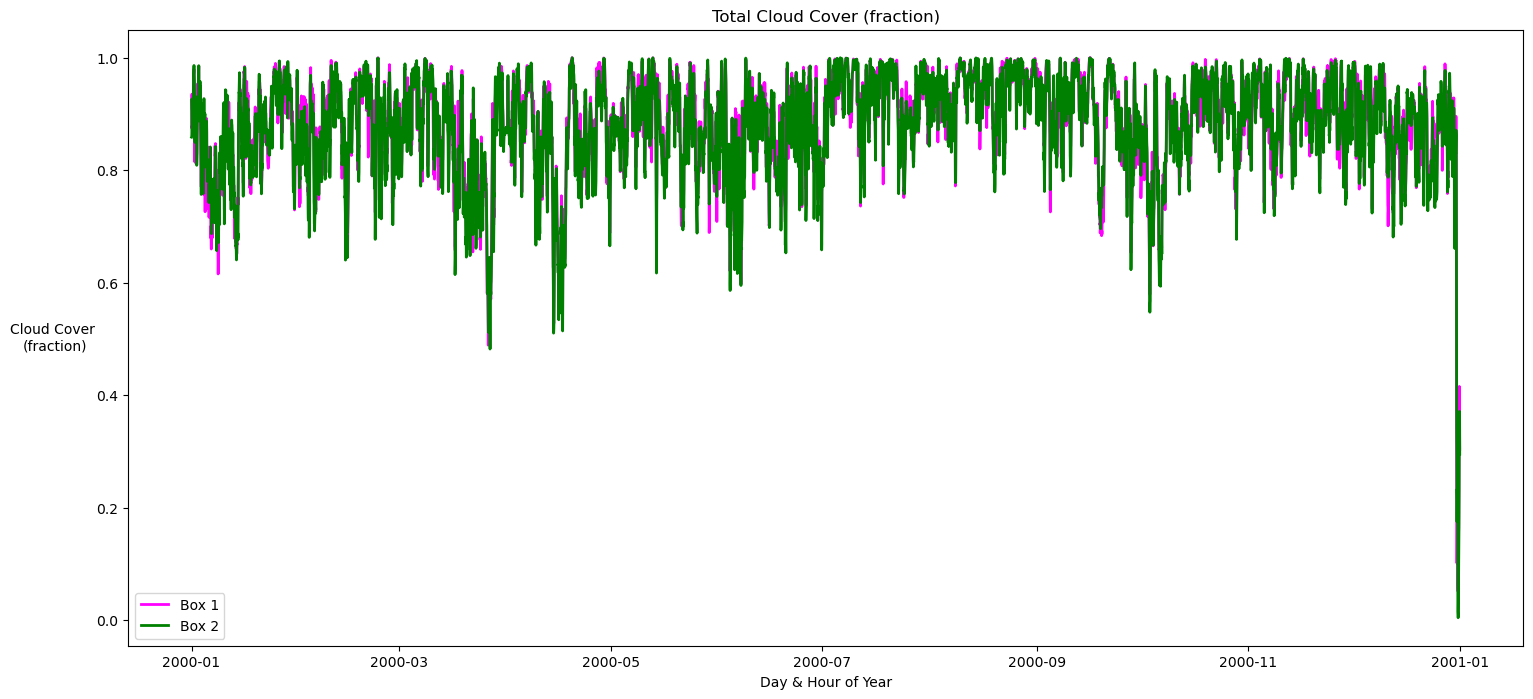

In [14]:
# Make day of year array
day_of_year = np.arange(1, 367, 1)

# Make new time index 
doy_w_hour = np.arange(1, 8785, 1)
hourly_datetimes = pd.date_range(start='2000-01-01', periods=366*24, freq='H')

# Make the figure
fig, ax = plt.subplots(figsize=(18,8))

# Longwave
ax.plot(hourly_datetimes, cloud_reg1_avg_doy_hrly2, color='magenta', linewidth=2, label='Box 1')
ax.plot(hourly_datetimes, cloud_reg2_avg_doy_hrly2, color='green', linewidth=2, label='Box 2')
ax.set_title('Total Cloud Cover (fraction)')
ax.set_ylabel('Cloud Cover \n(fraction)', rotation=0, va='center', labelpad=30)
ax.legend()
ax.set_xlabel('Day & Hour of Year')

Text(0.5, 0, 'Day & Hour of Year')

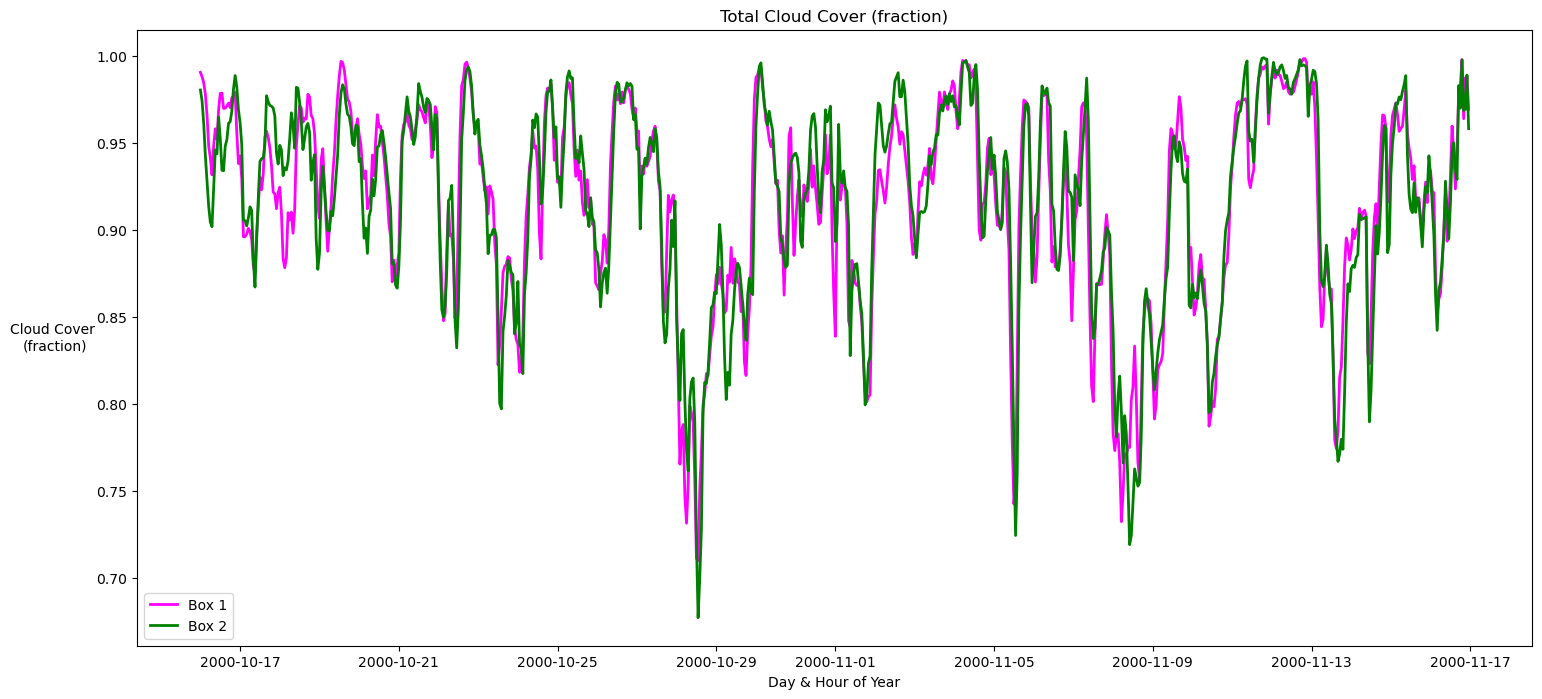

In [15]:
# Trim to just the period we want
# Plot the values around freeze-up which is mid-October to mid-November (ish)
# September 15 - October 15 = days 289 - 320 (leap year)

# Make the figure
fig, ax = plt.subplots(figsize=(18,8))

# Longwave
ax.plot(hourly_datetimes[289*24:321*24], cloud_reg1_avg_doy_hrly2[289*24:321*24], color='magenta', linewidth=2, label='Box 1')
ax.plot(hourly_datetimes[289*24:321*24], cloud_reg2_avg_doy_hrly2[289*24:321*24], color='green', linewidth=2, label='Box 2')
ax.set_title('Total Cloud Cover (fraction)')
ax.set_ylabel('Cloud Cover \n(fraction)', rotation=0, va='center', labelpad=30)
ax.legend()
ax.set_xlabel('Day & Hour of Year')

In [16]:
# Before fitting a sine curve to this, shift the data
# to start in mid-October to make it easier for fitting

cloud_reg1_avg_doy_hrly2_oct_start_pt1 = cloud_reg1_avg_doy_hrly2[((289*24)+1):]
cloud_reg1_avg_doy_hrly2_oct_start_pt2 = cloud_reg1_avg_doy_hrly2[:((289*24)+1)]

# Now combine/append these two parts to get a ~9 month time series 
cloud_reg1_avg_doy_hrly2_oct_start = np.concatenate((cloud_reg1_avg_doy_hrly2_oct_start_pt1, cloud_reg1_avg_doy_hrly2_oct_start_pt2))

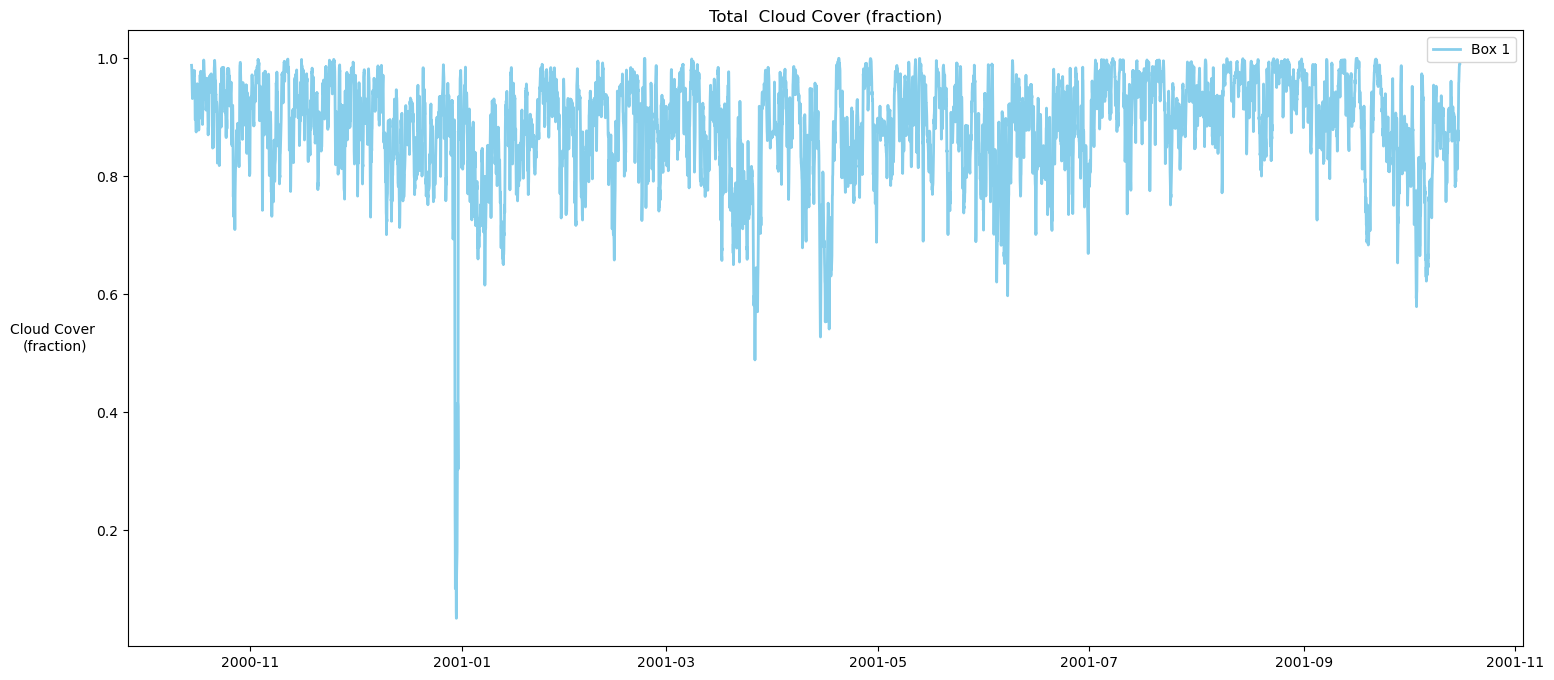

In [17]:
# Plot this to see how it looks

# Make shifted datetimes
hourly_datetimes_shifted = pd.date_range(start='2000-10-15', periods=366*24, freq='H')

# Plot the data
# Make the figure
fig, ax = plt.subplots(figsize=(18,8))

# Longwave
ax.plot(hourly_datetimes_shifted, cloud_reg1_avg_doy_hrly2_oct_start, color='skyblue', linewidth=2, label='Box 1')

#ax.plot(hourly_datetimes, longwave_reg2_avg_doy_hrly2, color='green', linewidth=2, label='Box 2')
ax.set_title('Total  Cloud Cover (fraction)')
ax.set_ylabel('Cloud Cover \n(fraction)', rotation=0, va='center', labelpad=30)
#ax.xaxis.set_visible(False)
ax.legend()

In [21]:
# For precipitation, make a sine wave fit 
# to use for idealized version
# Work on a fit...
# Focus on Box 1 since that is the one we will base everything 
# else on
from scipy.optimize import curve_fit

# Define a function to make an inital guess of a sine wave
def sine_function(x, amplitude, frequency, phase, offset):
        return amplitude * np.sin(frequency * x + phase) + offset

# Initial guess for parameters (amplitude, frequency, phase, offset)
initial_guess = [0.1, ((1/(366*24))/4), 0, 0.9]

# Convert time to hours since initial date to help with sine fit
time0 = hourly_datetimes[0]
numeric_time = (hourly_datetimes - time0) / np.timedelta64(1, 'h')

# Calculate/Fit parameters based on real data and the initial guess
params, covariance = curve_fit(sine_function, numeric_time, cloud_reg1_avg_doy_hrly2_oct_start, p0=initial_guess)

# Pull out the parameters
amplitude_fit, frequency_fit, phase_fit, offset_fit = params

# Use these new parameters to make a new sine function that fits the data
y_fit = sine_function(numeric_time, amplitude_fit, frequency_fit, phase_fit, offset_fit)

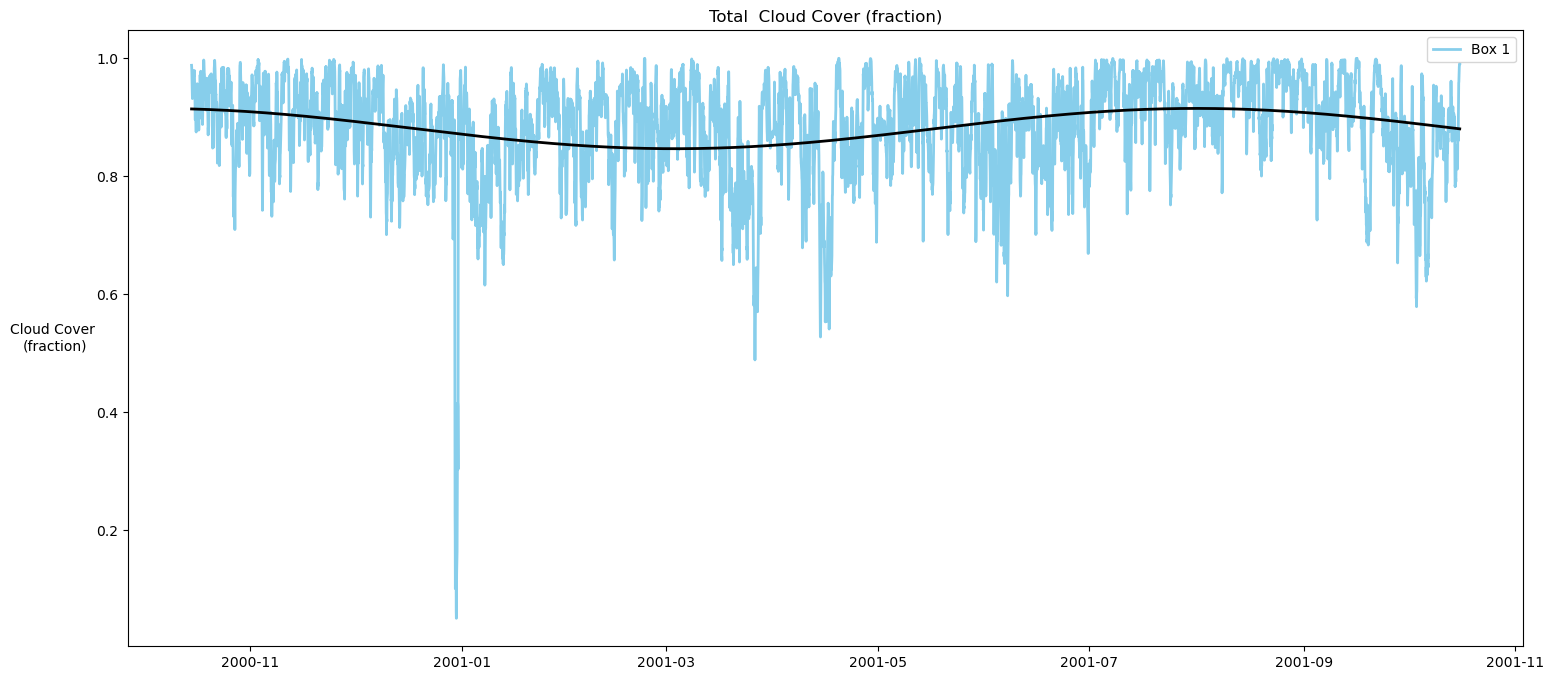

In [22]:
# Plot to see how this looks 

# Plot the data
# Make the figure
fig, ax = plt.subplots(figsize=(18,8))

# Longwave
ax.plot(hourly_datetimes_shifted, cloud_reg1_avg_doy_hrly2_oct_start, color='skyblue', linewidth=2, label='Box 1')
ax.plot(hourly_datetimes_shifted, y_fit, color='black', linewidth=2)

#ax.plot(hourly_datetimes, longwave_reg2_avg_doy_hrly2, color='green', linewidth=2, label='Box 2')
ax.set_title('Total  Cloud Cover (fraction)')
ax.set_ylabel('Cloud Cover \n(fraction)', rotation=0, va='center', labelpad=30)
#ax.xaxis.set_visible(False)
ax.legend()

In [24]:
# This is really not great but I think it is 
# close enough for now to see if this fixes noise things 
# or not soooo just go with it

In [25]:
# Ignore diurnal wiggles for now

In [26]:
# Now pull out 9 months starting at October
# (shifted above so no need to shift here)
sine_fit_no_diurnal_reg1 = y_fit
idealized_cloud_reg1 = sine_fit_no_diurnal_reg1[:((289*24)+1)]

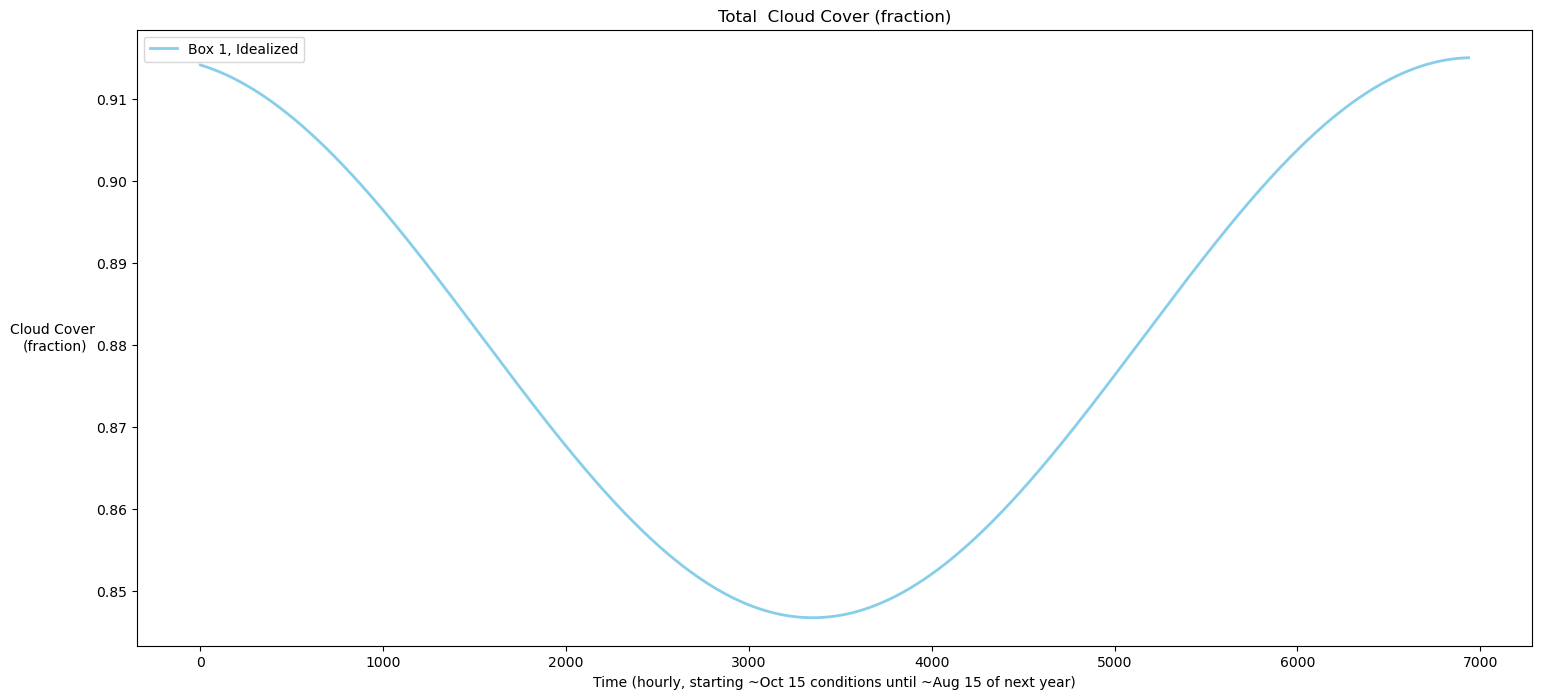

In [27]:
# Plot the idealized forcing 
# Make the figure
fig, ax = plt.subplots(figsize=(18,8))

# Longwave
ax.plot(idealized_cloud_reg1, color='skyblue', linewidth=2, label='Box 1, Idealized')
ax.set_title('Total  Cloud Cover (fraction)')
ax.set_ylabel('Cloud Cover \n(fraction)', rotation=0, va='center', labelpad=30)
ax.set_xlabel('Time (hourly, starting ~Oct 15 conditions until ~Aug 15 of next year)')
#ax.xaxis.set_visible(False)
ax.legend()

In [28]:
# Print the equation for the sine fit
print('Sine fit')
print('amplitude: ', amplitude_fit)
print('frequency: ', frequency_fit)
print('phase: ', phase_fit)
print('offsset: ', offset_fit)
#y_fit = sine_function(numeric_time, amplitude_fit, frequency_fit, phase_fit, offset_fit)

Sine fit
amplitude:  0.03412898412530543
frequency:  0.0008697618191813296
phase:  -4.483257557627266
offsset:  0.8808581496325072


### Set up the NetCDF  

The idealized model does not have any ties to lat/lon so the data can just be given in grid space rather than lat/lon and does not need to be interpolated or anything since it is spatially uniform. So we need to load the in the grid and then maybe remake this file any time you remake the grid.

In [29]:
# Load in the idealized model grid to get the dimensions 
# 500 m
#grid = xr.open_dataset('/global/homes/b/bundzis/Projects/Beaufort_ROMS_idealized_jet/Include/grd_500m_002.nc')
# 1 km
grid = xr.open_dataset('/global/homes/b/bundzis/Projects/Beaufort_ROMS_idealized_jet/Include/grd_1km_span_500km_noise_001.nc')

In [30]:
grid

<xarray.Dataset> Size: 12MB
Dimensions:      (eta_rho: 502, xi_rho: 202, eta_psi: 501, xi_psi: 201,
                  eta_u: 502, xi_u: 201, eta_v: 501, xi_v: 202)
Dimensions without coordinates: eta_rho, xi_rho, eta_psi, xi_psi, eta_u, xi_u,
                                eta_v, xi_v
Data variables: (12/18)
    x_rho        (eta_rho, xi_rho) float64 811kB ...
    y_rho        (eta_rho, xi_rho) float64 811kB ...
    x_psi        (eta_psi, xi_psi) float64 806kB ...
    y_psi        (eta_psi, xi_psi) float64 806kB ...
    x_u          (eta_u, xi_u) float64 807kB ...
    y_u          (eta_u, xi_u) float64 807kB ...
    ...           ...
    angle        (eta_rho, xi_rho) float64 811kB ...
    spherical    bool 1B ...
    xl           float64 8B ...
    el           float64 8B ...
    visc_factor  (eta_rho, xi_rho) float64 811kB ...
    diff_factor  (eta_rho, xi_rho) float64 811kB ...

In [31]:
# Pull out grid dimensions 
# Read in the dimensions
# rho
eta_rho_len = len(grid.eta_rho) # 206
xi_rho_len = len(grid.xi_rho) # 608
print('eta_rho_len: ', eta_rho_len)
print('xi_rho_len: ', xi_rho_len)
# u
eta_u_len = len(grid.eta_u) # 206
xi_u_len = len(grid.xi_u) # 607
print('eta_u_len: ', eta_u_len)
print('xi_u_len: ', xi_u_len)
# v
eta_v_len = len(grid.eta_v) #
xi_v_len = len(grid.xi_v) # 
print('eta_v_len: ', eta_v_len)
print('xi_v_len: ', xi_v_len)

# Define other dimension lengths
# eta rho
Mp = len(grid.eta_rho)
# xi rho
Lp = len(grid.xi_rho)
print('Mp: ', Mp)
print('Lp: ', Lp)

# # latitude
# lat_u_len = len(grid.lat_u)
# lat_v_len = len(grid.lat_v)
# print('lat_u_len: ', lat_u_len)
# print('lat_v_len: ', lat_v_len)

# # longitude
# lon_u_len = len(grid.lon_u)
# lon_v_len = len(grid.lon_v)
# print('lon_u_len: ', lon_u_len)
# print('lon_v_len: ', lon_v_len)

eta_rho_len:  502
xi_rho_len:  202
eta_u_len:  502
xi_u_len:  201
eta_v_len:  501
xi_v_len:  202
Mp:  502
Lp:  202


In [32]:
# Get the length of time for the data

# convert all the times to seconds since the first time step so it is on generic time)
#time_tmp = ((hourly_datetimes_shifted[:] - datetime(0,12,31)).total_seconds() - 86400)
time_tmp_1 = ((hourly_datetimes_shifted[:] - hourly_datetimes_shifted[0]).total_seconds())
# Trim to just the time we want
time_tmp = time_tmp_1[:len(idealized_cloud_reg1)]
# Get the length from this 
# time
time_len = len(time_tmp)

In [33]:
time_tmp

Index([       0.0,     3600.0,     7200.0,    10800.0,    14400.0,    18000.0,
          21600.0,    25200.0,    28800.0,    32400.0,
       ...
       24937200.0, 24940800.0, 24944400.0, 24948000.0, 24951600.0, 24955200.0,
       24958800.0, 24962400.0, 24966000.0, 24969600.0],
      dtype='float64', length=6937)

In [34]:
print('len time_tmp: ', len(time_tmp))
print('len hourly_datetimes_shifted: ', len(hourly_datetimes_shifted))
print('len idealized_air_temp_reg1: ', len(idealized_cloud_reg1))

len time_tmp:  6937
len hourly_datetimes_shifted:  8784
len idealized_air_temp_reg1:  6937


In [35]:
# Make a version of the code that is this shape and same everywhere
idealized_cloud_reg1_ongrid = np.empty((time_len, eta_rho_len, xi_rho_len))

# Loop through space and fill with the idealized version
for y in range(eta_rho_len):
    for x in range(xi_rho_len):
        idealized_cloud_reg1_ongrid[:,y,x] = idealized_cloud_reg1

# Could insert a check for this at some point...

In [36]:
# Unit check
print('ERA5 cloud cover units: ', era5_cloud.tcc.units)

ERA5 cloud cover units:  (0 - 1)


In [37]:
# Make the netcdf for the forcing file 

# ------------------------------- Create the netCDF file ---------------------------

#name of file I am writing to
# 500 m
#tair_frc = '/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/Forcing_files/idealized_cloud_forcing_500m_002.nc'   #UPDATE PATH
# 1 km
cloud_frc = '/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/Forcing_files/idealized_cloud_forcing_1km_span_500km_001.nc'   #UPDATE PATH

#create file to write to
nc1 = Dataset(cloud_frc, 'w', format='NETCDF4')

#Global attributes
global_defaults = dict(gridname = '*.nc',
                      type = 'ROMS grid shaped ERA5 idealized cloud cover forcing',
                      history = 'Created by Brianna Undzis',
                      Conventions = 'CF',
                      Institution = 'University of Colorado Boulder',
                      date = str(datetime.today()))
    
#create dictionary for model
d = {}
d = global_defaults

for att, value in d.items():
    setattr(nc1, att, value)

# Create dimensions
nc1.createDimension('xi_rho',  xi_rho_len)   # rho
nc1.createDimension('eta_rho', eta_rho_len)
# nc1.createDimension('lon',  era5_lon_len)   # rho
# nc1.createDimension('lat', era5_lat_len)
nc1.createDimension('cloud_time', None)
nc1.createDimension('one',     1)

# Create variables 
# --------------------
# Coordinate Variables
# --------------------
# # era5 lon
# lon = nc1.createVariable('lon', 'd', ('lon',), zlib=True)
# lon.long_name = 'longitude coordinate of ERA5 data'
# lon.standard_name = 'projection_lon_coordinate'
# lon.units = 'degrees'
# lon_tmp = era5_longwave.longitude
# lon[:] = lon_tmp[:]

# # era5 lat
# lat = nc1.createVariable('lat', 'd', ('lat',), zlib=True)
# lat.long_name = 'latitude coordinate of ERA5 data'
# lat.standard_name = 'projection_lat_coordinate'
# lat.units = 'degrees'
# #lat_tmp = era5_longwave.latitude
# lat_tmp = lat_flip # FLIP
# lat[:] = lat_tmp[:]

# xi rho
xi_rho = nc1.createVariable('xi_rho', 'd', ('xi_rho',), zlib=True)
xi_rho.long_name = 'xi coordinate of RHO-points'
xi_rho.standard_name = 'projection_xi_coordinate'
xi_rho.units = 'meter'
xi_rho_tmp = np.arange(0, Lp)
xi_rho[:] = xi_rho_tmp[:]

# eta rho
eta_rho = nc1.createVariable('eta_rho', 'd', ('eta_rho',), zlib=True)
eta_rho.long_name = 'eta coordinate of RHO-points'
eta_rho.standard_name = 'projection_eta_coordinate'
eta_rho.units = 'meter'
eta_rho_tmp = np.arange(0, Mp)
eta_rho[:] = eta_rho_tmp[:]

# cloud_time (in seconds)
cloud_time_g = nc1.createVariable('cloud_time', None, ('cloud_time'), zlib=True)
cloud_time_g.long_name = 'seconds since 2000-01-01 00:00:00' #with initialization of 2000-01-01 00:00:00
cloud_time_g.units = 'second'
cloud_time_g.field = 'time, scalar, series'
cloud_time_g[:] = time_tmp[:]


# --------------------
# Atmospheric Variables 
# --------------------

# cloud cover
cloud_interp_g = nc1.createVariable('cloud', 'f8', ('cloud_time', 'eta_rho', 'xi_rho'), zlib=True, fill_value=1e30)
cloud_interp_g.long_name = 'cloud fraction'
cloud_interp_g.standard_name = 'cloud_area_fraction'
cloud_interp_g.units = 'nondimensional' 
cloud_interp_g.coordinates = 'eta_rho xi_rho'
cloud_interp_g[:,:,:] = idealized_cloud_reg1_ongrid[:,:,:]


nc1.close()
# ------------------------------- End netCDF ---------------------------